# Introduction into the effect of site


Magnetic Resonance Imaging (MRI) studies are increasingly conducted across multiple imaging sites and scanners in order to collect larger and more diverse datasets. While multi-site studies improve statistical power and generalisability, they also introduce an important challenge: site effects (sometimes called scanner effects or batch effects).

Site effects arise because MRI measurements can vary depending on:

- Scanner manufacturer and model

- Imaging protocols and acquisition parameters

- Hardware calibration

- Coil differences

- Software versions

- Environmental and operational factors

Even when imaging protocols are carefully harmonised, subtle differences between scanners can still influence the appearance of images and the quantitative measures derived from them.

In this tutorial, we will explore how image-level differences propagate into downstream analyses and how these effects can bias statistical interpretation if they are not properly considered.

### Tutorial contents

- Identify visual differences between MRI scans acquired at different sites

- Understand how scanner effects influence image intensity distributions and image quality metrics

- Explore how derived imaging phenotypes (IDPs) can vary across scanners

- Simulate multi-site datasets with batch effects

- Understand how confounding variables and scanner effects can distort biological interpretation

- Reflect on why harmonisation methods are important in large neuroimaging studies

## Section 1.1: Exploring image level differences

We will begin by examining structural MRI data from the *ON-Harmony travelling-heads study* [1]. In this dataset, the same participant was scanned at multiple imaging sites, allowing us to isolate scanner-related differences while keeping biological variation constant.

The acquisition protocols in this study were designed to be as consistent as possible across scanners. Despite this harmonisation effort, measurable differences still remain between images. The data have also been defaced according to UK Biobank protocols to protect participant privacy. This preprocessing step does not affect the derived brain measurements used in this tutorial.

We will begin by viewing some data from the ON-Harmony study using a single image viewer.
This data is from one participant, at two different sites.[1]

We show here the T1 data, as it is the most commonly use modality.

As you inspect the scans, think carefully about the following:

- Do the overall image intensities appear similar?

- Is one image noisier than the other?

- Does tissue contrast differ between scans?

- Are anatomical boundaries equally clear?

- Could these differences influence automated measurements such as hippocampal volume or cortical thickness?

These observations will motivate the later statistical analyses in the notebook.

In [ ]:
from block1_utils.ImageViewerBlock1 import MRIImageViewer
import matplotlib.pyplot as plt 
import pathlib

# 1. Display the example data from one subject in two different sessions using the provided viewer:
#  notebooks/block01/data/*.nii
DATA_DIR = pathlib.Path("../../data/data_block1")
# Load the images, they are converted to arrays for ease within the MRIimage viewer class
img1 = DATA_DIR / "Philips.nii"
img2 = DATA_DIR / "GE.nii"

# We also have the T1 images registered (affine) to the MNI space, you can also load these to see that registration to a standard space
# will improve heterogeneity across scanners, but we will not use these for the rest of the course
#img1 = DATA_DIR / "Philips_brain_mni.nii.gz"
#img2 = DATA_DIR / "GE_brain_mni.nii.gz"

viewer1 = MRIImageViewer(img1, img2)
viewer1.show()

## Section 1.2: Basic image level statistics

As previously mentioned, the protocols in this study were designed to be as similar to each other as scanners were allowed to be. Despite this, the overall intensities, SNR, CNR and even brain anatomy looks incredible different.

Still working at the image level; we can view some of these differences as plots.

- Histogram of intensities 

- Number of non-zero voxels

See if there is a difference when using the registered image vs the raw image


Image 1 - Non-zero voxel count: 28.24%
Image 2 - Non-zero voxel count: 26.76%


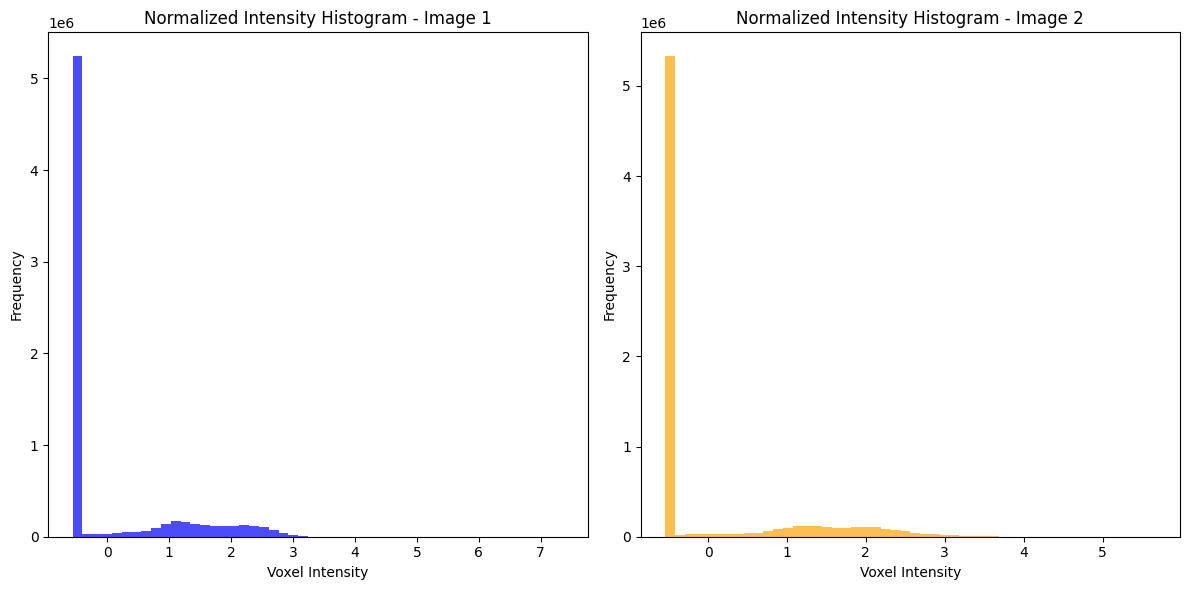

In [10]:
from block1_utils.ImageStatsBlock1 import IntensityHistogram
from block1_utils.ImageStatsBlock1 import NonZeroVoxelCount

# Count the number of non-zero voxels in each image, divide by total number of voxels to get the percentage of non-zero voxels, and print the results.
NonZeroVoxelCount(img1, img2)

# Plot the distribution of intensities
IntensityHistogram(img1, img2)

## Section 1.3: ROI/IDP differences due to scanner effects:

Differences observed at the image level often propagate into downstream quantitative measurements.

To compare anatomical structures more meaningfully across scans, MRI images are typically aligned to a standard anatomical space such as MNI152 using image registration techniques such as FSL FNIRT.[2][3][4]
After spatial normalisation, we can estimate regional brain measurements such as:

- Regional volumes

- Cortical measurements

- Tissue properties

- Morphometric biomarkers

These measurements are often referred to as Imaging-Derived Phenotypes (IDPs).
In doing so, we are able to compare different regional volumes in a more meaningful way. The full processing of this data is described in the ON-Harmony dataset and we only use the IDPs here;

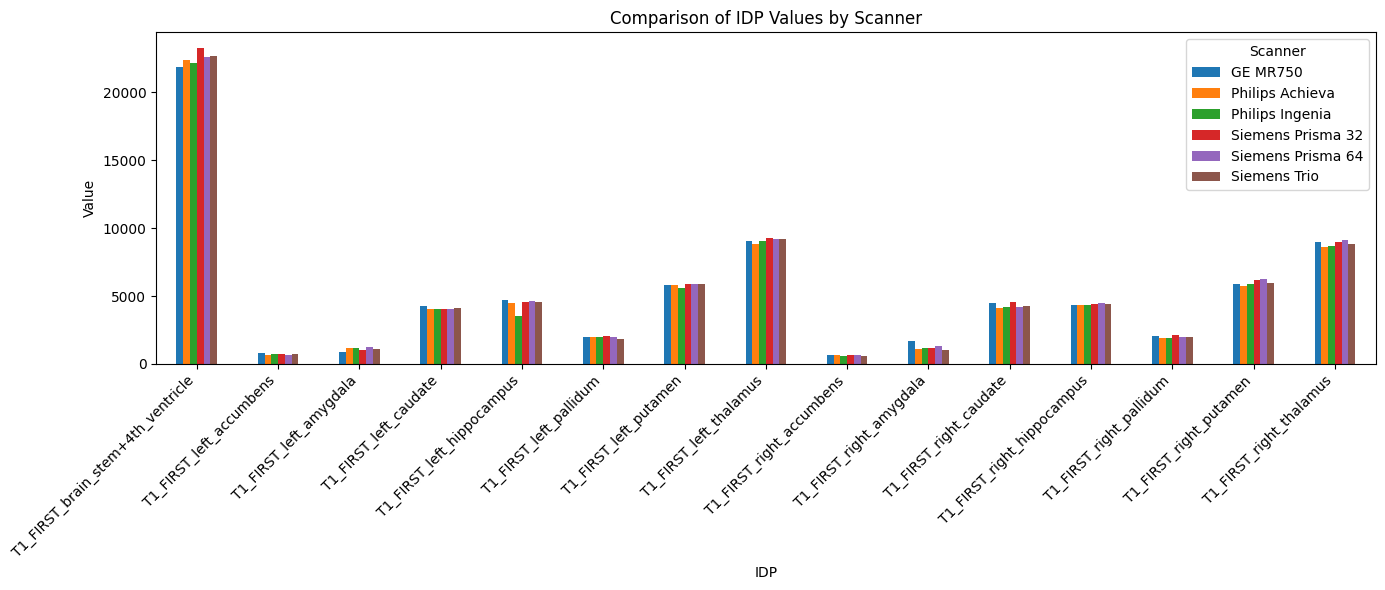

In [ ]:
# Comparing the IDPs from FSL-FIRST of different ROIs across the two sessions, and plotting the results.
from block1_utils.ImageStatsBlock1 import compareIDPs
compareIDPs(DATA_DIR / "ON_Harmony_example_IDPs.csv")

There are a few things to notice about these measures, write some down and think about some reasons as why this might be the case